In [2]:
from autoreduce import *
import numpy as np

?

$ \dot{x} = f(x,\Theta) \quad \\ \quad
y = Cx \quad \\ \quad
x =
\begin{bmatrix}
P \\
C_1 \\
T \\
R \\
C_2 \\
X
\end{bmatrix}
\quad \\ \quad
\Theta =
\begin{bmatrix}
k_{bp} \\
k_{up} \\
k_{tx} \\
k_{br} \\
k_{ur} \\
k_{tl} \\
d_T \\
d_X \\
G
\end{bmatrix}
\quad \\ \quad
y = X $

$
\begin{aligned}
\dot{P} &= (k_{up}+k_{tx})C_1 - k_{bp}GP \\
\dot{C}_1 &= k_{bp}GP - (k_{up}+k_{tx})C_1 \\
\dot{T} &= k_{tx}C_1 + (k_{ur}+k_{tl})C_2 - k_{br}TR - d_TT \\
\dot{R} &= (k_{ur}+k_{tl})C_2 - k_{br}TR \\
\dot{C}_2 &= k_{br}TR - (k_{ur}+k_{tl})C_2 \\
\dot{X} &= k_{tl}C_2 - d_XX
\end{aligned}
$

Used the previous michaelis-mention example as skeleton code, but adjusted it to fit the equations above, changed the varaible we care about to x[5], (X protein)

In [3]:
from autoreduce import *
import numpy as np
import matplotlib.pyplot as plt

# Full protein expression model
n = 6
nouts = 1

# parameters:
# P[0] = kbp
# P[1] = kup
# P[2] = ktx
# P[3] = kbr
# P[4] = kur
# P[5] = ktl
# P[6] = dT
# P[7] = dX
# P[8] = G

P = np.zeros(9)

P[0] = 10     # kbp
P[1] = 10     # kup
P[2] = 1      # ktx
P[3] = 10     # kbr
P[4] = 10     # kur
P[5] = 1      # ktl
P[6] = 0.1    # dT
P[7] = 0.1    # dX
P[8] = 1      # G

params_values = P.copy()
timepoints_ode = np.linspace(0, 150, 100)

x_init = np.zeros(n)

error_tol = 100
nstates_tol = 2

x, f, P = load_ODE_model(n, len(params_values))
params = P

# x[0] = P_free
# x[1] = C1
# x[2] = T
# x[3] = R_free
# x[4] = C2
# x[5] = X protein

f[0] = (P[1] + P[2])*x[1] - P[0]*P[8]*x[0]

f[1] = P[0]*P[8]*x[0] - (P[1] + P[2])*x[1]

f[2] = P[2]*x[1] + (P[4] + P[5])*x[4] - P[3]*x[2]*x[3] - P[6]*x[2]

f[3] = (P[4] + P[5])*x[4] - P[3]*x[2]*x[3]

f[4] = P[3]*x[2]*x[3] - (P[4] + P[5])*x[4]

f[5] = P[5]*x[4] - P[7]*x[5]

C = np.zeros((nouts, len(x)), dtype=int)
C[0][5] = 1
C = C.tolist()

sys = System(
    x,
    f,
    params=params,
    C=C,
    params_values=params_values,
    x_init=x_init
)

In [4]:
sys.x

[x0, x1, x2, x3, x4, x5]

In [5]:
# from autoreduce.utils import get_SSM
# timepoints_ssm = np.linspace(0,60,10)
# sys_ssm = get_SSM(sys, timepoints_ssm)
# Ss = sys_ssm.compute_SSM(normalize = True) # len(timepoints) x len(params) x len(states)
# out_Ss = []
# for i in range(len(params)):
#     out_Ss.append((np.array(C)@(Ss[:,i,:].T)))
# out_Ss = np.reshape(np.array(out_Ss), (len(timepoints_ssm), len(params), nouts))

In [6]:
try:
    import seaborn as sn
    for j in range(nouts):
        sn.heatmap(out_Ss[:,:,j].T)
        plt.xlabel('Time')
        plt.ylabel('Parameters')
        plt.title('Sensitivity of output[{0}] with respect to all parameters'.format(j))
        plt.show()
except:
    print('Plotting libraries missing.')

Plotting libraries missing.


In [7]:
from autoreduce.utils import get_reducible
timepoints_ssm = np.linspace(0,60,10)
timepoints_ode = np.linspace(0, 100, 100)
sys_reduce = get_reducible(sys, timepoints_ode, timepoints_ssm)
results = sys_reduce.reduce_simple(skip_numerical_computation = True,skip_error_computation = True, skip_robustness_computation = True)
#results = sys_reduce.reduce_simple()

Could not find solution for: x1 from 0
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P4 + P5)*(P2*x1 + P4*x4 + P5*x4)/(P2*x1*(P6 + P6*x4*(P4 + P5)/(P2*x1)))
Could not find solution for: x1 from 0
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P4 + P5)*(P2*x1 + P4*x4 + P5*x4)/(P2*x1*(P6 + P6*x4*(P4 + P5)/(P2*x1)))
Could not find solution for: x1 from 0
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P4 + P5)*(P2*x1 + P4*x4 + P5*x4)/(P2*x1*(P6 + P6*x4*(P4 + P5)/(P2*x1)))
Could not find solution for: x1 from 0


C:\Users\angel\autoreduce\autoreduce\model_reduction.py:1215: UserWarning: Solve time-scale separation failed. Check model consistency.
  warnings.warn(


Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P4 + P5)*(P2*x1 + P4*x4 + P5*x4)/(P2*x1*(P6 + P6*x4*(P4 + P5)/(P2*x1)))
Did not work to retain: [x5] because either a collapsed state-variables appears
 in the reduced model or a solution is not possible.


C:\Users\angel\autoreduce\autoreduce\model_reduction.py:470: UserWarning: Solve time-scale separation failed.Check model consistency.
  warnings.warn(


Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P1 + P2)*(P4 + P5)*(P0*P2*P8*x0 + P1*P4*x4 + P1*P5*x4 + P2*P4*x4 + P2*P5*x4)/(P0*P2*P8*x0*(P1*P6 + P2*P6 + P1*P6*x4*(P1 + P2)*(P4 + P5)/(P0*P2*P8*x0) + P6*x4*(P1 + P2)*(P4 + P5)/(P0*P8*x0)))
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P1 + P2)*(P4 + P5)*(P0*P2*P8*x0 + P1*P4*x4 + P1*P5*x4 + P2*P4*x4 + P2*P5*x4)/(P0*P2*P8*x0*(P1*P6 + P2*P6 + P1*P6*x4*(P1 + P2)*(P4 + P5)/(P0*P2*P8*x0) + P6*x4*(P1 + P2)*(P4 + P5)/(P0*P8*x0)))
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P1 + P2)*(P4 + P5)*(P0*P2*P8*x0 + P1*P4*x4 + P1*P5*x4 + P2*P4*x4 + P2*P5*x4)/(P0*P2*P8*x0*(P1*P6 + P2*P6 + P1*P6*x4*(P1 + P2)*(P4 + P5)/(P0*P2*P8*x0) + P6*x4*(P1 + P2)*(P4 + P5)/(P0*P8*x0)))
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P1 + P2)*(P4 + P5)*(P0*P2*P8*x0 + P1*P4*x4 + P1*P5*x4 + P2*P4*x4 + P2*P5*x4)/(P0*P2*P8*x0*(P1*P6 + P2*P6 + P1*P6*x4*(P1 + P2)*(P4 + P5)/(P0*P2*P8*x0) + P6*x4*(P1 + P2)*(P4 + P5)/(P0*P8*x0

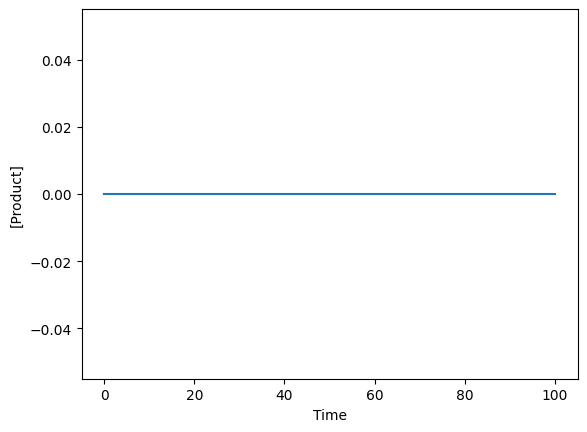

In [8]:
from autoreduce.utils import get_ODE
sys_ode = get_ODE(sys, timepoints_ode)
sol = sys_ode.solve_system().T
#try:
import matplotlib.pyplot as plt
plt.plot(timepoints_ode, np.transpose(np.array(C)@sol))
plt.xlabel('Time')
plt.ylabel('[Product]')
plt.show()
#except:
#    print('Plotting libraries missing.')

In [ ]:
all_reduced = list(results.keys())

[x0, x3, x5]